In [ ]:
!pip install apache-beam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31

In [ ]:
import apache_beam as beam

In [ ]:
data = spark.read.csv('/content/iris.data')

In [ ]:
data.show(1)

+---+---+---+---+-----------+
|_c0|_c1|_c2|_c3|        _c4|
+---+---+---+---+-----------+
|5.1|3.5|1.4|0.2|Iris-setosa|
+---+---+---+---+-----------+
only showing top 1 row



In [ ]:
import apache_beam as beam

# Create a pipeline using DirectRunner (default for local execution)
with beam.Pipeline() as pipeline:
    numbers = (
        pipeline
        | 'Create Numbers' >> beam.Create([1, 2, 3, 4, 5])  # Creating a PCollection
        | 'Multiply by 10' >> beam.Map(lambda x: x * 10)  # Applying transformation
    )

    # Use beam.Map(print) to force evaluation and print the results
    numbers | 'Print Results' >> beam.Map(print)



10
20
30
40
50


In [ ]:
with beam.Pipeline() as pipeline:
  data =  (
      pipeline
      | "read csv file" >> beam.io.ReadFromText('/content/iris.data')
      | "Parse CSV" >> beam.Map(lambda line: line.split(','))


  )

  data | 'show result' >> beam.Map(print)

['5.1', '3.5', '1.4', '0.2', 'Iris-setosa']
['4.9', '3.0', '1.4', '0.2', 'Iris-setosa']
['4.7', '3.2', '1.3', '0.2', 'Iris-setosa']
['4.6', '3.1', '1.5', '0.2', 'Iris-setosa']
['5.0', '3.6', '1.4', '0.2', 'Iris-setosa']
['5.4', '3.9', '1.7', '0.4', 'Iris-setosa']
['4.6', '3.4', '1.4', '0.3', 'Iris-setosa']
['5.0', '3.4', '1.5', '0.2', 'Iris-setosa']
['4.4', '2.9', '1.4', '0.2', 'Iris-setosa']
['4.9', '3.1', '1.5', '0.1', 'Iris-setosa']
['5.4', '3.7', '1.5', '0.2', 'Iris-setosa']
['4.8', '3.4', '1.6', '0.2', 'Iris-setosa']
['4.8', '3.0', '1.4', '0.1', 'Iris-setosa']
['4.3', '3.0', '1.1', '0.1', 'Iris-setosa']
['5.8', '4.0', '1.2', '0.2', 'Iris-setosa']
['5.7', '4.4', '1.5', '0.4', 'Iris-setosa']
['5.4', '3.9', '1.3', '0.4', 'Iris-setosa']
['5.1', '3.5', '1.4', '0.3', 'Iris-setosa']
['5.7', '3.8', '1.7', '0.3', 'Iris-setosa']
['5.1', '3.8', '1.5', '0.3', 'Iris-setosa']
['5.4', '3.4', '1.7', '0.2', 'Iris-setosa']
['5.1', '3.7', '1.5', '0.4', 'Iris-setosa']
['4.6', '3.6', '1.0', '0.2', 'Ir

In [ ]:
data.Map(print)

AttributeError: 'PCollection' object has no attribute 'Map'

In [ ]:
with beam.Pipeline() as pipeline:
  data =  (
      pipeline
      | "read csv file" >> beam.io.ReadFromText('/content/iris.data')
      | "Parse CSV" >> beam.Map(lambda line: line.split(","))  # Split into list
      | "Infer Schema" >> beam.Map(lambda row: {"setal": row[0], "petal": float(row[1]), "length": float(row[2]), "breath": float(row[3]), "status": str(row[4])})
  )

  data | 'show result' >> beam.Map(print)

ERROR:apache_beam.runners.common:list index out of range [while running '[37]: Infer Schema']
Traceback (most recent call last):
  File "apache_beam/runners/common.py", line 1501, in apache_beam.runners.common.DoFnRunner.process
  File "apache_beam/runners/common.py", line 690, in apache_beam.runners.common.SimpleInvoker.invoke_process
  File "/usr/local/lib/python3.11/dist-packages/apache_beam/transforms/core.py", line 2086, in <lambda>
    wrapper = lambda x: [fn(x)]
                         ^^^^^
  File "<ipython-input-37-23fd8bbe34b8>", line 6, in <lambda>
    | "Infer Schema" >> beam.Map(lambda row: {"setal": row[0], "petal": float(row[1]), "length": float(row[2]), "breath": float(row[3]), "status": str(row[4])})
                                                                              ~~~^^^
IndexError: list index out of range


{'setal': '5.1', 'petal': 3.5, 'length': 1.4, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.9', 'petal': 3.0, 'length': 1.4, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.7', 'petal': 3.2, 'length': 1.3, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.6', 'petal': 3.1, 'length': 1.5, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '5.0', 'petal': 3.6, 'length': 1.4, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '5.4', 'petal': 3.9, 'length': 1.7, 'breath': 0.4, 'status': 'Iris-setosa'}
{'setal': '4.6', 'petal': 3.4, 'length': 1.4, 'breath': 0.3, 'status': 'Iris-setosa'}
{'setal': '5.0', 'petal': 3.4, 'length': 1.5, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.4', 'petal': 2.9, 'length': 1.4, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.9', 'petal': 3.1, 'length': 1.5, 'breath': 0.1, 'status': 'Iris-setosa'}
{'setal': '5.4', 'petal': 3.7, 'length': 1.5, 'breath': 0.2, 'status': 'Iris-setosa'}
{'setal': '4.8', 'petal': 3.4, 'length': 1.6, 'breath'

IndexError: list index out of range [while running '[37]: Infer Schema']

"|" is a beam operator which applies a PTransform to a PCollection.

">>" allows you to name a step in your pipeline. Names of the transform steps should be unique.



In [ ]:
import apache_beam as beam
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Create a SparkSession
spark = SparkSession.builder.appName("BeamToPySpark").getOrCreate()

# Define the schema for PySpark DataFrame
schema = StructType([
    StructField("sepal_length", DoubleType(), True),
    StructField("sepal_width", DoubleType(), True),
    StructField("petal_length", DoubleType(), True),
    StructField("petal_width", DoubleType(), True),
    StructField("species", StringType(), True)
])

# Function to parse CSV rows into tuples, handling lines with insufficient fields
def parse_csv(line):
    fields = line.split(",")
    if len(fields) >= 5:  # Check if line has enough fields
        return (
            fields[0],
            fields[1],
            fields[2],
            fields[3],
            fields[4].strip()
        )
    else:
        print(f"Skipping line: {line}")  # Log or handle skipped lines
        return None  # Or return a default value

# Run Apache Beam pipeline
with beam.Pipeline() as pipeline:
    pcollection = (
        pipeline
        | "Read CSV" >> beam.io.ReadFromText("/content/iris.data", skip_header_lines=1)
        | "Parse CSV" >> beam.Map(parse_csv)  # Convert to tuple
        | "Collect Data" >> beam.combiners.ToList()
    )

    # Run pipeline and extract results
    result = pipeline.run().wait_until_finish()

# Since PCollection is collected as a list, manually extract it
collected_data = list(result) # Get the result from the PCollection

Skipping line: 
Skipping line: 


In [ ]:
import apache_beam as beam
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, FloatType


spark = SparkSession.builder.appName("BeamToSpark").getOrCreate()


schema = StructType([
    StructField("sepal_length", FloatType(), True),
    StructField("sepal_width", FloatType(), True),
    StructField("petal_length", FloatType(), True),
    StructField("petal_width", FloatType(), True),
    StructField("species", StringType(), True)
])

# Function to safely parse each line
def parse_line(line):
    fields = line.split(',')
    if len(fields) != 5:
        return None  # Skip invalid rows
    else:
        return f"{float(fields[0])},{float(fields[1])},{float(fields[2])},{float(fields[3])},{fields[4]}"


output_path = "/content/beam_output.csv"

# Apache Beam Pipeline
with beam.Pipeline() as pipeline:
    data = (
        pipeline
        | "Read CSV" >> beam.io.ReadFromText('/content/iris.data')
        | "Remove Empty Lines" >> beam.Filter(lambda line: line.strip() != "")
        | "Parse and Format CSV" >> beam.Map(parse_line)
        | "Filter Valid Rows" >> beam.Filter(lambda row: row is not None)
        | "Write to File" >> beam.io.WriteToText(output_path, file_name_suffix=".csv", shard_name_template="")
    )

# Read the processed data into a PySpark DataFrame
df = spark.read.csv(output_path + ".csv", schema=schema, header=False)

# Show DataFrame
df.show()

#df = spark.createDataFrame(data, schema= schema)


+------------+-----------+------------+-----------+-----------+
|sepal_length|sepal_width|petal_length|petal_width|    species|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
|         5.4|        3.9|         1.7|        0.4|Iris-setosa|
|         4.6|        3.4|         1.4|        0.3|Iris-setosa|
|         5.0|        3.4|         1.5|        0.2|Iris-setosa|
|         4.4|        2.9|         1.4|        0.2|Iris-setosa|
|         4.9|        3.1|         1.5|        0.1|Iris-setosa|
|         5.4|        3.7|         1.5|        0.2|Iris-setosa|
|         4.8|        3.4|         1.6|        0.2|Iris-setosa|
|         4.8|        3.0|         1.4| 

In [ ]:
import apache_beam as beam
from apache_beam.options.pipeline_options import PipelineOptions
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, FloatType

# Initialize Spark Session
spark = SparkSession.builder.appName("BeamToSpark").getOrCreate()

# Define schema for PySpark DataFrame
schema = StructType([
    StructField("sepal_length", FloatType(), True),
    StructField("sepal_width", FloatType(), True),
    StructField("petal_length", FloatType(), True),
    StructField("petal_width", FloatType(), True),
    StructField("species", StringType(), True)
])

# Function to safely parse each line
def parse_line(line):
    fields = line.split(',')
    if len(fields) != 5:
        return None  # Skip invalid rows
    else:
        return (float(fields[0]), float(fields[1]), float(fields[2]), float(fields[3]), fields[4])

# Define pipeline options
options = PipelineOptions()

# Create an empty list to collect results
collected_data = []

# Apache Beam Pipeline
def run_pipeline():
    with beam.Pipeline(options=options) as pipeline:
        processed_data = (
            pipeline
            | "Read CSV" >> beam.io.ReadFromText('/content/iris.data')
            | "Remove Empty Lines" >> beam.Filter(lambda line: line.strip() != "")
            | "Parse CSV" >> beam.Map(parse_line)
            | "Filter Valid Rows" >> beam.Filter(lambda row: row is not None)
            | "Collect to List" >> beam.combiners.ToList()
        )

        # Apply a side effect to capture data
        def collect_result(data):
            collected_data.extend(data)  # Append results to the Python list

        processed_data | "Capture Data" >> beam.Map(collect_result)

        # Run the pipeline
        result = pipeline.run()
        result.wait_until_finish()

# Execute Beam pipeline
run_pipeline()

# Convert collected list to PySpark DataFrame
df = spark.createDataFrame(collected_data, schema=schema)

# Show DataFrame
df.show()


+------------+-----------+------------+-----------+-----------+
|sepal_length|sepal_width|petal_length|petal_width|    species|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
|         5.4|        3.9|         1.7|        0.4|Iris-setosa|
|         4.6|        3.4|         1.4|        0.3|Iris-setosa|
|         5.0|        3.4|         1.5|        0.2|Iris-setosa|
|         4.4|        2.9|         1.4|        0.2|Iris-setosa|
|         4.9|        3.1|         1.5|        0.1|Iris-setosa|
|         5.4|        3.7|         1.5|        0.2|Iris-setosa|
|         4.8|        3.4|         1.6|        0.2|Iris-setosa|
|         4.8|        3.0|         1.4| 

In [ ]:
import apache_beam as beam

with beam.Pipeline() as pipeline:
    pcoll = (
        pipeline
        | "Create Rows" >> beam.Create([
            beam.Row(name="Alice", age=30),
            beam.Row(name="Bob", age=25),
        ])
        | "Add Extra Column" >> beam.Map(lambda row: beam.Row(name=row.name, age=row.age, city="New York"))
        | "Print Results" >> beam.Map(print)
    )


Row(name='Alice', age=30, city='New York')
Row(name='Bob', age=25, city='New York')


In [ ]:
import apache_beam as beam

with beam.Pipeline() as pipeline:
    pcoll = (
        pipeline
        | "Create Rows" >> beam.Create([
            beam.Row(first_name="Alice", last_name="Smith"),
            beam.Row(first_name="Bob", last_name="Johnson"),
        ])
        | "Add Full Name Column" >> beam.Map(lambda row:
            beam.Row(first_name=row.first_name,
                     last_name=row.last_name,
                     full_name=row.first_name + " " + row.last_name))
        | "Print Results" >> beam.Map(print)
    )


Row(first_name='Alice', last_name='Smith', full_name='Alice Smith')
Row(first_name='Bob', last_name='Johnson', full_name='Bob Johnson')


**PipelineOptions in Apache Beam**


PipelineOptions is the mechanism in Apache Beam to configure and customize pipeline execution.
It allows users to specify settings such as runner type, job parameters, input/output locations, and other execution details.

In [ ]:
!pip install apache-beam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31

In [ ]:
import apache_beam as beam
from apache_beam.options.pipeline_options import PipelineOptions

# Create options
options = PipelineOptions()

# Create pipeline with options
with beam.Pipeline(options=options) as pipeline:
    (
        pipeline
        | "Read" >> beam.io.ReadFromText("input.txt")
        | "Write" >> beam.io.WriteToText("output.txt")
    )


we can create a custom option

In [ ]:
from apache_beam.options.pipeline_options import PipelineOptions
from apache_beam.options.pipeline_options import StandardOptions

class MyOptions(PipelineOptions):
    @classmethod
    def _add_argparse_args(cls, parser):
        parser.add_argument('--input', help='Input file path')
        parser.add_argument('--output', help='Output file path')

# Parse custom options
options = MyOptions()
input_path = options.input
output_path = options.output

# Use in pipeline
with beam.Pipeline(options=options) as pipeline:
    (
        pipeline
        | "Read" >> beam.io.ReadFromText(input_path)
        | "Write" >> beam.io.WriteToText(output_path)
    )


we can pass the description for any specific keyword

In [ ]:
from apache_beam.options.pipeline_options import PipelineOptions

class MyOptions(PipelineOptions):
    @classmethod
    def _add_argparse_args(cls, parser):
        parser.add_argument(
            '--input',
            help='Path to the input file (e.g., gs://my-bucket/input.txt)'
        )
        parser.add_argument(
            '--output',
            help='Path to the output file (e.g., gs://my-bucket/output.txt)'
        )
        parser.add_argument(
            '--num_workers',
            type=int,
            default=2,
            help='Number of workers to use for execution'
        )

# Parsing options
options = MyOptions()

# Accessing values
print(f"Input: {options.input}")
print(f"Output: {options.output}")
print(f"Workers: {options.num_workers}")


**Pcollection**

A PCollection (short for Parallel Collection) is the core data structure in Apache Beam. It represents a distributed dataset that can be processed in parallel. You can think of it like a Resilient Distributed Dataset (RDD) in Apache Spark.



🔹 Key Features of PCollection

✔ Immutable – Once created, it cannot be modified; transformations create new PCollections.

✔ Distributed – Data is processed across multiple nodes in parallel.

✔ Can be Bounded or Unbounded – It can represent both batch (finite) and streaming (infinite) data.

✔ Lazy Evaluation – Operations on a PCollection are executed only when the pipeline runs.

***Transformation**

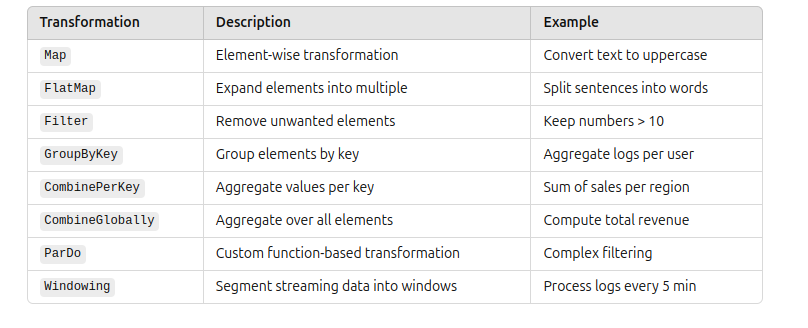

In [ ]:
#map
import apache_beam as beam

with beam.Pipeline() as pipeline:
    pcoll = pipeline | "Create Numbers" >> beam.Create([1, 2, 3, 4, 5])

    squared = pcoll | "Square Numbers" >> beam.Map(lambda x: x * x)

    squared | "Print Results" >> beam.Map(print)


1
4
9
16
25


In [ ]:
#flatmap
with beam.Pipeline() as pipeline:
    sentences = pipeline | "Create Sentences" >> beam.Create(["hello world", "apache beam"])

    words = sentences | "Split Words" >> beam.FlatMap(lambda sentence: sentence.split())

    words | "Print Words" >> beam.Map(print)


hello
world
apache
beam


In [ ]:
#filter
with beam.Pipeline() as pipeline:
    numbers = pipeline | "Create Numbers" >> beam.Create([1, 2, 3, 4, 5, 6])

    evens = numbers | "Filter Even Numbers" >> beam.Filter(lambda x: x % 2 == 0)

    evens | "Print Even Numbers" >> beam.Map(print)


2
4
6


In [ ]:
#groupbykey

with beam.Pipeline() as pipeline:
    pairs = pipeline | "Create Pairs" >> beam.Create([
        ('user1', 10), ('user2', 20), ('user1', 30), ('user2', 40)
    ])

    grouped = pairs | "Group by Key" >> beam.GroupByKey()

    grouped | "Print Grouped Data" >> beam.Map(print)


('user1', [10, 30])
('user2', [20, 40])


In [ ]:
#CombinePerKey

with beam.Pipeline() as pipeline:
    sales = pipeline | "Create Sales Data" >> beam.Create([
        ('store1', 100), ('store2', 150), ('store1', 200), ('store2', 250)
    ])

    total_sales = sales | "Sum Sales Per Store" >> beam.CombinePerKey(sum)

    total_sales | "Print Sales" >> beam.Map(print)


('store1', 300)
('store2', 400)


In [ ]:
#CombineGlobally

with beam.Pipeline() as pipeline:
    numbers = pipeline | "Create Numbers" >> beam.Create([10, 20, 30, 40])

    total = numbers | "Sum All Numbers" >> beam.CombineGlobally(sum)

    total | "Print Total" >> beam.Map(print)


100


**CoGroupByKey**

CoGroupByKey is used in Apache Beam to join multiple PCollections by a common key. It works similarly to SQL JOIN or cogroup in PySpark.

In [ ]:
#CoGroupByKey
with beam.Pipeline() as pipeline:
  student_pairs = pipeline | 'Create icons' >> beam.Create([
      ('vignesh', 'bangalore'),
      ('khaula', 'hyderabad'),
      ('neethu', 'malapur'),
      ('sai', 'chennai'),
  ])

  student_result = pipeline | 'Create durations' >> beam.Create([
      ('vignesh', [15,"FAIL"]),
      ('khaula', [99,"PASS"]),
      ('neethu', [100,"PASS"]),
      ('sai',[ 37,"FAIL"]),
  ])

  plants = (({
      'icons': student_pairs, 'durations': student_result
  })
            | 'Merge' >> beam.CoGroupByKey()
            | beam.Map(print))

('vignesh', {'icons': ['bangalore'], 'durations': [[15, 'FAIL']]})
('khaula', {'icons': ['hyderabad'], 'durations': [[99, 'PASS']]})
('neethu', {'icons': ['malapur'], 'durations': [[100, 'PASS']]})
('sai', {'icons': ['chennai'], 'durations': [[37, 'FAIL']]})


In [ ]:
#ParDo

class MultiplyByTwo(beam.DoFn):
    def process(self, element):
        yield element * 2

with beam.Pipeline() as pipeline:
    numbers = pipeline | "Create Numbers" >> beam.Create([1, 2, 3, 4])

    doubled = numbers | "Multiply by 2" >> beam.ParDo(MultiplyByTwo())

    doubled | "Print Results" >> beam.Map(print)


2
4
6
8


In [ ]:
#Windowing

import apache_beam.transforms.window as window

with beam.Pipeline() as pipeline:
    stream_data = pipeline | "Read Streaming Data" >> beam.io.ReadFromPubSub(topic="projects/my-project/topics/my-topic")

    windowed_data = stream_data | "Apply Fixed Window" >> beam.WindowInto(window.FixedWindows(60))  # 60-second window


Exception: PubSub I/O is only available in streaming mode (use the --streaming flag).

**DoFn Lifecycle in Apache Beam**

A DoFn (short for "Do Function") is the core processing unit in Apache Beam’s ParDo transformation. It defines how each element in a PCollection is processed.

Apache Beam follows a structured lifecycle for DoFn, which includes setup, per-element processing, and teardown

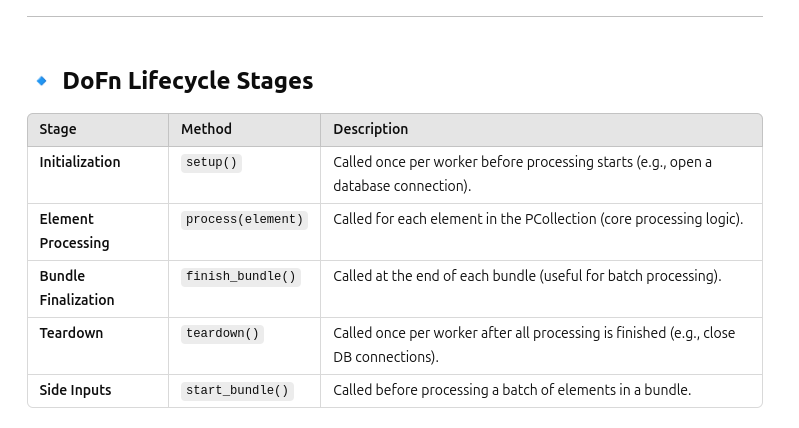

In [ ]:
!pip install apache_beam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
import apache_beam as beam

class MyDoFn(beam.DoFn):
    def setup(self):
        """Called once per worker before processing starts."""
        print("Setting up resources (e.g., DB connection)")

    def start_bundle(self):
        """Called at the beginning of a bundle."""
        print("Start processing a bundle of elements")

    def process(self, element):
        """Called for each element in the PCollection."""
        print(f"Processing element: {element}")
        yield element * 2

    def finish_bundle(self):
        """Called at the end of a bundle."""
        print("Finished processing a bundle")

    def teardown(self):
        """Called once per worker after processing completes."""
        print("Cleaning up resources (e.g., closing DB connection)")

# Running the pipeline
with beam.Pipeline() as pipeline:
    numbers = pipeline | "Create Data" >> beam.Create([1, 2, 3, 4])

    processed = numbers | "Apply DoFn" >> beam.ParDo(MyDoFn())

    processed | "Print Results" >> beam.Map(print)


Setting up resources (e.g., DB connection)
Start processing a bundle of elements
Processing element: 1
2
Processing element: 2
4
Processing element: 3
6
Processing element: 4
8
Finished processing a bundle
Cleaning up resources (e.g., closing DB connection)


**CoGroupByKey**

CoGroupByKey performs a relational join of two or more key/value PCollections that have the same key type

In [ ]:
emails_list = [
    ('amy', 'amy@example.com'),
    ('carl', 'carl@example.com'),
    ('julia', 'julia@example.com'),
    ('carl', 'carl@email.com'),
]
phones_list = [
    ('amy', '111-222-3333'),
    ('james', '222-333-4444'),
    ('amy', '333-444-5555'),
    ('carl', '444-555-6666'),
]

emails = p | 'CreateEmails' >> beam.Create(emails_list)
phones = p | 'CreatePhones' >> beam.Create(phones_list)
results = ({'emails': emails, 'phones': phones} | beam.CoGroupByKey())

def join_info(name_info):
  (name, info) = name_info
  return '%s; %s; %s' %\
      (name, sorted(info['emails']), sorted(info['phones']))

contact_lines = results | beam.Map(join_info)


(1, ['Alice'], ['Laptop', 'Mouse'])
(2, ['Bob'], ['Keyboard'])
(3, ['Charlie'], ['Monitor', 'Desk'])


**GroupIntoBatches**

group the all element in a fixd length

In [ ]:

with beam.Pipeline() as pipeline:
  batches_with_keys = (
      pipeline
      | 'Create produce' >> beam.Create([
          ('spring', '1'),
          ('spring', '2'),
          ('spring', '3'),
          ('spring', '4'),
          ('summer', '5'),
          ('summer', '1'),
          ('summer', '2'),
          ('fall', '1'),
          ('fall', '2'),
          ('winter', '1'),
      ])
      | 'Group into batches' >> beam.GroupIntoBatches(4)
      | beam.Map(print))


NameError: name 'beam' is not defined

**Combine**

In [ ]:
from apache_beam.options.pipeline_options import PipelineOptions
options = PipelineOptions()

In [ ]:
#testing

import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row and concatenates first and last name."""
    fields = row.split(",")
    if len(fields) < 6:
        return None

    full_name = f"{fields[1]} {fields[2]}"
    return (fields[0], fields[1], fields[2], full_name, fields[3], fields[4], fields[5])

def capture_data(data_list):
    global data_captured
    data_captured = data_list

with beam.Pipeline() as pipeline:
    transformed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        | "Filter None" >> beam.Filter(lambda x: x is not None)
        | "Collect to List" >> beam.combiners.ToList()
        | "captured the data" >> beam.Map(capture_data)
    )

    transformed_data | "Print Results" >> beam.Map(print)


None


In [ ]:
print(data_captured)

[('1', 'John', 'Doe', 'John Doe', '30', '60000', 'IT'), ('2', 'Jane', 'Smith', 'Jane Smith', '25', '55000', 'HR'), ('3', 'Michael', 'Johnson', 'Michael Johnson', '35', '75000', 'Finance'), ('4', 'Emily', 'Davis', 'Emily Davis', '28', '58000', 'Marketing'), ('5', 'Daniel', 'Martinez', 'Daniel Martinez', '40', '90000', 'IT'), ('6', 'Sophia', 'Lopez', 'Sophia Lopez', '27', '62000', 'HR'), ('7', 'James', 'Gonzalez', 'James Gonzalez', '45', '110000', 'Finance'), ('8', 'Olivia', 'Wilson', 'Olivia Wilson', '32', '70000', 'Marketing'), ('9', 'William', 'Anderson', 'William Anderson', '29', '63000', 'IT'), ('10', 'Ava', 'Thomas', 'Ava Thomas', '26', '59000', 'HR'), ('11', 'Alexander', 'Taylor', 'Alexander Taylor', '38', '85000', 'Finance'), ('12', 'Mia', 'Moore', 'Mia Moore', '24', '54000', 'Marketing'), ('13', 'Ethan', 'Jackson', 'Ethan Jackson', '31', '67000', 'IT'), ('14', 'Charlotte', 'White', 'Charlotte White', '33', '72000', 'HR'), ('15', 'Benjamin', 'Harris', 'Benjamin Harris', '37', '78

In [ ]:
schema  = StructType([
      StructField("id", StringType(), True),
      StructField("first_name", StringType(), True),
      StructField("last_name", StringType(), True),
      StructField("full_name", StringType(), True),
      StructField("age", StringType(), True),
      StructField("salary", StringType(), True),
      StructField("department", StringType(), True),
    ])


In [ ]:
df1 =  spark.createDataFrame(data_captured, schema)

In [ ]:
df1.show()

+---+----------+---------+----------------+---+------+----------+
| id|first_name|last_name|       full_name|age|salary|department|
+---+----------+---------+----------------+---+------+----------+
|  1|      John|      Doe|        John Doe| 30| 60000|        IT|
|  2|      Jane|    Smith|      Jane Smith| 25| 55000|        HR|
|  3|   Michael|  Johnson| Michael Johnson| 35| 75000|   Finance|
|  4|     Emily|    Davis|     Emily Davis| 28| 58000| Marketing|
|  5|    Daniel| Martinez| Daniel Martinez| 40| 90000|        IT|
|  6|    Sophia|    Lopez|    Sophia Lopez| 27| 62000|        HR|
|  7|     James| Gonzalez|  James Gonzalez| 45|110000|   Finance|
|  8|    Olivia|   Wilson|   Olivia Wilson| 32| 70000| Marketing|
|  9|   William| Anderson|William Anderson| 29| 63000|        IT|
| 10|       Ava|   Thomas|      Ava Thomas| 26| 59000|        HR|
| 11| Alexander|   Taylor|Alexander Taylor| 38| 85000|   Finance|
| 12|       Mia|    Moore|       Mia Moore| 24| 54000| Marketing|
| 13|     

In [ ]:
capture_data = []
def store_data(data_list):
    global capture_data
    capture_data = data_list

with beam.Pipeline () as pipeline:
    data = (
        pipeline
        | "read file" >> beam.io.ReadFromText('/content/sample - Sheet1.csv')
        | "collect to list" >> beam.combiners.ToList()
        | "store data" >> beam.Map(store_data)
    )
    data | "Print Results" >> beam.Map(print) # it will not return anythings bcz the data is directly append in list(i.e. globally declared above)


None


In [ ]:
print(capture_data)

['id,first_name,last_name,age,salary,department', '1,John,Doe,30,60000,IT', '2,Jane,Smith,25,55000,HR', '3,Michael,Johnson,35,75000,Finance', '4,Emily,Davis,28,58000,Marketing', '5,Daniel,Martinez,40,90000,IT', '6,Sophia,Lopez,27,62000,HR', '7,James,Gonzalez,45,110000,Finance', '8,Olivia,Wilson,32,70000,Marketing', '9,William,Anderson,29,63000,IT', '10,Ava,Thomas,26,59000,HR', '11,Alexander,Taylor,38,85000,Finance', '12,Mia,Moore,24,54000,Marketing', '13,Ethan,Jackson,31,67000,IT', '14,Charlotte,White,33,72000,HR', '15,Benjamin,Harris,37,78000,Finance', '16,Amelia,Clark,29,64000,Marketing', '17,Lucas,Robinson,42,98000,IT', '18,Harper,Walker,30,66000,HR', '19,Mason,Hall,34,74000,Finance', '20,Evelyn,Allen,27,60000,Marketing']


In [ ]:
import pyspark
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder.appName('sample_operation').getOrCreate()

In [ ]:
# Extract header and data
header = capture_data[0].split(",")
data_rows = [row.split(",") for row in capture_data[1:]]

In [ ]:
print(header)

['id', 'first_name', 'last_name', 'age', 'salary', 'department']


In [ ]:
print(data_rows)

[['1', 'John', 'Doe', '30', '60000', 'IT'], ['2', 'Jane', 'Smith', '25', '55000', 'HR'], ['3', 'Michael', 'Johnson', '35', '75000', 'Finance'], ['4', 'Emily', 'Davis', '28', '58000', 'Marketing'], ['5', 'Daniel', 'Martinez', '40', '90000', 'IT'], ['6', 'Sophia', 'Lopez', '27', '62000', 'HR'], ['7', 'James', 'Gonzalez', '45', '110000', 'Finance'], ['8', 'Olivia', 'Wilson', '32', '70000', 'Marketing'], ['9', 'William', 'Anderson', '29', '63000', 'IT'], ['10', 'Ava', 'Thomas', '26', '59000', 'HR'], ['11', 'Alexander', 'Taylor', '38', '85000', 'Finance'], ['12', 'Mia', 'Moore', '24', '54000', 'Marketing'], ['13', 'Ethan', 'Jackson', '31', '67000', 'IT'], ['14', 'Charlotte', 'White', '33', '72000', 'HR'], ['15', 'Benjamin', 'Harris', '37', '78000', 'Finance'], ['16', 'Amelia', 'Clark', '29', '64000', 'Marketing'], ['17', 'Lucas', 'Robinson', '42', '98000', 'IT'], ['18', 'Harper', 'Walker', '30', '66000', 'HR'], ['19', 'Mason', 'Hall', '34', '74000', 'Finance'], ['20', 'Evelyn', 'Allen', '27

In [ ]:
df =  spark.createDataFrame(data_rows, header)

In [ ]:
df.show()

+---+----------+---------+---+------+----------+
| id|first_name|last_name|age|salary|department|
+---+----------+---------+---+------+----------+
|  1|      John|      Doe| 30| 60000|        IT|
|  2|      Jane|    Smith| 25| 55000|        HR|
|  3|   Michael|  Johnson| 35| 75000|   Finance|
|  4|     Emily|    Davis| 28| 58000| Marketing|
|  5|    Daniel| Martinez| 40| 90000|        IT|
|  6|    Sophia|    Lopez| 27| 62000|        HR|
|  7|     James| Gonzalez| 45|110000|   Finance|
|  8|    Olivia|   Wilson| 32| 70000| Marketing|
|  9|   William| Anderson| 29| 63000|        IT|
| 10|       Ava|   Thomas| 26| 59000|        HR|
| 11| Alexander|   Taylor| 38| 85000|   Finance|
| 12|       Mia|    Moore| 24| 54000| Marketing|
| 13|     Ethan|  Jackson| 31| 67000|        IT|
| 14| Charlotte|    White| 33| 72000|        HR|
| 15|  Benjamin|   Harris| 37| 78000|   Finance|
| 16|    Amelia|    Clark| 29| 64000| Marketing|
| 17|     Lucas| Robinson| 42| 98000|        IT|
| 18|    Harper|   W

Captured Data: ['id,first_name,last_name,age,salary,department', '1,John,Doe,30,60000,IT', '2,Jane,Smith,25,55000,HR', '3,Michael,Johnson,35,75000,Finance', '4,Emily,Davis,28,58000,Marketing', '5,Daniel,Martinez,40,90000,IT', '6,Sophia,Lopez,27,62000,HR', '7,James,Gonzalez,45,110000,Finance', '8,Olivia,Wilson,32,70000,Marketing', '9,William,Anderson,29,63000,IT', '10,Ava,Thomas,26,59000,HR', '11,Alexander,Taylor,38,85000,Finance', '12,Mia,Moore,24,54000,Marketing', '13,Ethan,Jackson,31,67000,IT', '14,Charlotte,White,33,72000,HR', '15,Benjamin,Harris,37,78000,Finance', '16,Amelia,Clark,29,64000,Marketing', '17,Lucas,Robinson,42,98000,IT', '18,Harper,Walker,30,66000,HR', '19,Mason,Hall,34,74000,Finance', '20,Evelyn,Allen,27,60000,Marketing']


In [ ]:
print(data_captured)

[(BeamSchema_13ce4e6b_9f26_48ca_940e_65901e08c7b3(), [('60000', 'IT'), ('55000', 'HR'), ('75000', 'Finance'), ('58000', 'Marketing'), ('90000', 'IT'), ('62000', 'HR'), ('110000', 'Finance'), ('70000', 'Marketing'), ('63000', 'IT'), ('59000', 'HR'), ('85000', 'Finance'), ('54000', 'Marketing'), ('67000', 'IT'), ('72000', 'HR'), ('78000', 'Finance'), ('64000', 'Marketing'), ('98000', 'IT'), ('66000', 'HR'), ('74000', 'Finance'), ('60000', 'Marketing')])]


In [ ]:
head = data_captured[0]
print(head)

(BeamSchema_13ce4e6b_9f26_48ca_940e_65901e08c7b3(), [('60000', 'IT'), ('55000', 'HR'), ('75000', 'Finance'), ('58000', 'Marketing'), ('90000', 'IT'), ('62000', 'HR'), ('110000', 'Finance'), ('70000', 'Marketing'), ('63000', 'IT'), ('59000', 'HR'), ('85000', 'Finance'), ('54000', 'Marketing'), ('67000', 'IT'), ('72000', 'HR'), ('78000', 'Finance'), ('64000', 'Marketing'), ('98000', 'IT'), ('66000', 'HR'), ('74000', 'Finance'), ('60000', 'Marketing')])


In [ ]:
schema  = StructType([
      StructField("salary", StringType(), True),
      StructField("department", StringType(), True),
    ])


In [ ]:
df2 =  spark.createDataFrame(data_captured, schema)

In [ ]:
#testing

import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row and concatenates first and last name."""
    fields = row.split(",")
    if len(fields) < 6:
        return None

    #full_name = f"{fields[1]} {fields[2]}"
    #return (fields[0], fields[1], fields[2], full_name, fields[3], fields[4], fields[5])
    return (fields[4], fields[5])

def capture_data(data_list):
    global data_captured
    data_captured = data_list

with beam.Pipeline() as pipeline:
    transformed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        | "Filter None" >> beam.Filter(lambda x: x is not None)
        | "Collect to List" >> beam.combiners.ToList()

        | "captured the data" >> beam.Map(capture_data)
    )


    transformed_data | "Print Results" >> beam.Map(print)


None


In [ ]:
print(data_captured)

[('60000', 'IT'), ('55000', 'HR'), ('75000', 'Finance'), ('58000', 'Marketing'), ('90000', 'IT'), ('62000', 'HR'), ('110000', 'Finance'), ('70000', 'Marketing'), ('63000', 'IT'), ('59000', 'HR'), ('85000', 'Finance'), ('54000', 'Marketing'), ('67000', 'IT'), ('72000', 'HR'), ('78000', 'Finance'), ('64000', 'Marketing'), ('98000', 'IT'), ('66000', 'HR'), ('74000', 'Finance'), ('60000', 'Marketing')]


In [ ]:
with beam.Pipeline() as pipeline:
    pairs = pipeline | "Create Pairs" >> beam.Create([
        ('user1', 10), ('user2', 20), ('user1', 30), ('user2', 40)
    ])

    grouped = pairs | "Group by Key" >> beam.GroupByKey()

    grouped | "Print Grouped Data" >> beam.Map(print)


In [ ]:
#testing

import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row and concatenates first and last name."""
    fields = row.split(",")
    if len(fields) < 6:
        return None

    #full_name = f"{fields[1]} {fields[2]}"
    #return (fields[0], fields[1], fields[2], full_name, fields[3], fields[4], fields[5])
    return (fields[4], fields[5])

def capture_data(data_list):
    global data_captured
    data_captured = data_list

with beam.Pipeline() as pipeline:
    transformed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        #| "Filter None" >> beam.Filter(lambda x: x is not None)
        #| "grouping the things" >> beam.CombinePerKey(sum)
        | "Collect to List" >> beam.combiners.ToList()

        #| "captured the data" >> beam.Map(capture_data)
    )


    transformed_data | "Print Results" >> beam.Map(print)


[('60000', 'IT'), ('55000', 'HR'), ('75000', 'Finance'), ('58000', 'Marketing'), ('90000', 'IT'), ('62000', 'HR'), ('110000', 'Finance'), ('70000', 'Marketing'), ('63000', 'IT'), ('59000', 'HR'), ('85000', 'Finance'), ('54000', 'Marketing'), ('67000', 'IT'), ('72000', 'HR'), ('78000', 'Finance'), ('64000', 'Marketing'), ('98000', 'IT'), ('66000', 'HR'), ('74000', 'Finance'), ('60000', 'Marketing')]


In [ ]:
import apache_beam as beam

def process_row(row):
    """Splits CSV row and extracts (Department, Salary) pairs."""
    fields = row.split(",")
    if len(fields) < 6:
        return []  # Return an empty list instead of None to avoid type mismatch
    return [(fields[5], int(fields[4]))]  # Wrap the tuple in a list for FlatMap

with beam.Pipeline() as pipeline:
    grouped_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.FlatMap(process_row)  # Use FlatMap to handle empty lists
        | "Group by Department" >> beam.GroupByKey()
        | "Print Results" >> beam.Map(print)
    )


('IT', [60000, 90000, 63000, 67000, 98000])
('HR', [55000, 62000, 59000, 72000, 66000])
('Finance', [75000, 110000, 85000, 78000, 74000])
('Marketing', [58000, 70000, 54000, 64000, 60000])


In [ ]:
!pip install apache_beam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31

In [ ]:
import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row, extracts necessary fields, and processes them."""
    fields = row.split(",")
    if len(fields) < 6:  # Ensure all fields exist
        return None

    id, first_name, last_name, age, salary, department = int(fields[0]), fields[1], fields[2], int(fields[3]), int(fields[4]), fields[5]
    full_name = f"{first_name} {last_name}"
    return (id, first_name, last_name, full_name, age, salary, department)

def capture_data(data_list):
    global data_captured
    data_captured = data_list
    print("Captured Data:", data_captured)  # Debugging output

with beam.Pipeline() as pipeline:
    # Read and process the CSV file
    processed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample - Sheet1.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        | "Filter None" >> beam.Filter(lambda x: x is not None)

    )
    # SUM: Total Salary per Department
    total_salary_per_dept = (
        processed_data
        | "Map Salary to Department" >> beam.Map(lambda x: (x[6], x[5]))  # (department, salary)
        | "Sum Salaries" >> beam.CombinePerKey(sum)
        #| "capture data" >> beam.Map(capture_data)
    )

    # AVG: Total Average Salary per Department

    avg_salary_per_dept = (
        processed_data
        | "Map Dept to (Salary,1)" >> beam.Map(lambda x: (x[6], (x[5], 1)))  # (department, (salary, 1))
        | "Sum Salary & Count" >> beam.CombinePerKey(lambda vals: (sum(s for s, _ in vals), sum(c for _, c in vals)))
        | "Calculate Avg" >> beam.Map(lambda x: (x[0], x[1][0] / x[1][1]))  # (dept, avg_salary)
    )
    # COUNT: Number of Employees per Department
    employee_count_per_dept = (
        processed_data
        | "Map Dept to 1" >> beam.Map(lambda x: (x[6], 1))  # (department, 1)
        | "Count Employees" >> beam.CombinePerKey(sum)
    )
    # WORD COUNT: First Name Frequency
    first_name_count = (
        processed_data
        | "Extract First Names" >> beam.FlatMap(lambda x: x[1].split())  # Split first names
        | "Pair With One" >> beam.Map(lambda name: (name, 1))  # (first_name, 1)
        | "Count Names" >> beam.CombinePerKey(sum)
    )
    # WORD COUNT: Last Name Frequency
    last_name_count =  (
        processed_data

    )


    # Print results separately to avoid breaking the pipeline

    first_name_count | "Print Total Salary" >> beam.Map(print)


('John', 1)
('Jane', 1)
('Michael', 1)
('Emily', 1)
('Daniel', 1)
('Sophia', 1)
('James', 1)
('Olivia', 1)
('William', 1)
('Ava', 1)
('Alexander', 1)
('Mia', 1)
('Ethan', 1)
('Charlotte', 1)
('Benjamin', 1)
('Amelia', 1)
('Lucas', 1)
('Harper', 1)
('Mason', 1)
('Evelyn', 1)


In [ ]:
print(data_captured)

[]


In [ ]:
import apache_beam as beam

data_captured = []

def process_row(row):
    """Splits CSV row, extracts necessary fields, and processes them."""
    fields = row.split(",")
    if len(fields) < 6:  # Ensure all fields exist
        return None

    id, first_name, last_name, age, salary, department = fields[0], fields[1], fields[2], int(fields[3]), float(fields[4]), fields[5]
    full_name = f"{first_name} {last_name}"
    return (id, first_name, last_name, full_name, age, salary, department)

def capture_data(data_list):
    global data_captured
    data_captured = data_list
    print("Captured Data:", data_captured)  # Debugging output

with beam.Pipeline() as pipeline:
    # Read and process the CSV file
    processed_data = (
        pipeline
        | "Read File" >> beam.io.ReadFromText('/content/sample.csv', skip_header_lines=1)
        | "Transform Data" >> beam.Map(process_row)
        | "Filter None" >> beam.Filter(lambda x: x is not None)
    )

    # SUM: Total Salary per Department
    total_salary_per_dept = (
        processed_data
        | "Map Salary to Department" >> beam.Map(lambda x: (x[6], x[5]))  # (department, salary)
        | "Sum Salaries" >> beam.CombinePerKey(sum)
    )

    # AVG: Average Salary per Department
    avg_salary_per_dept = (
        processed_data
        | "Map Dept to (Salary,1)" >> beam.Map(lambda x: (x[6], (x[5], 1)))  # (department, (salary, 1))
        | "Sum Salary & Count" >> beam.CombinePerKey(lambda vals: (sum(s for s, _ in vals), sum(c for _, c in vals)))
        | "Calculate Avg" >> beam.Map(lambda x: (x[0], x[1][0] / x[1][1]))  # (dept, avg_salary)
    )

    # COUNT: Number of Employees per Department
    employee_count_per_dept = (
        processed_data
        | "Map Dept to 1" >> beam.Map(lambda x: (x[6], 1))  # (department, 1)
        | "Count Employees" >> beam.CombinePerKey(sum)
    )

    # WORD COUNT: First Name Frequency
    first_name_count = (
        processed_data
        | "Extract First Names" >> beam.FlatMap(lambda x: x[1].split())  # Split first names
        | "Pair With One" >> beam.Map(lambda name: (name, 1))  # (first_name, 1)
        | "Count Names" >> beam.CombinePerKey(sum)
    )

    # Collect results
    (
        {
            "Total Salary": total_salary_per_dept,
            "Avg Salary": avg_salary_per_dept,
            "Employee Count": employee_count_per_dept,
            "First Name Count": first_name_count
        }
        | "Combine Results" >> beam.CoGroupByKey()
        | "Capture Data" >> beam.Map(capture_data)
    )


TypeError: Expected a CombineFn or callable, got <PCollection[[145]: Sum Salaries.None] at 0x7995d882e050>